# CC1 — Plano de Análise
**SIMA – Sistema Inteligente de Monitoramento e Alerta de Alagamentos**  
Cesar School · 5º Período CC · Trilha de Análise e Visualização de Dados

---

Este notebook documenta o **plano de análise** do SIMA: as perguntas investigativas, os dados previstos, as métricas a extrair e as visualizações planejadas, com justificativas baseadas em princípios de percepção e design visual.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# Paleta semântica SIMA
VERDE = '#10b981'
AMBAR = '#f59e0b'
VERM  = '#ef4444'
AZUL  = '#1d4ed8'
CINZA = '#64748b'
PRETO = '#0f172a'
FUNDO = '#f8fafc'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

## 1. Contexto e Objetivo

Recife é a 5ª cidade do Brasil em população exposta a riscos de inundação (IBGE). O SIMA coleta relatos de alagamento via crowdsourcing e os armazena em PostgreSQL. O banco conta com **41 relatos reais**, complementados por dados simulados calibrados nas mesmas proporções para viabilizar análise estatística.

**Objetivo:** transformar esses dados em inteligência operacional — identificar padrões que permitam antecipar situações de risco e orientar a Defesa Civil com evidências, não apenas alertas reativos.

O gráfico abaixo mostra o fluxo do sistema do ponto de coleta até a ação.

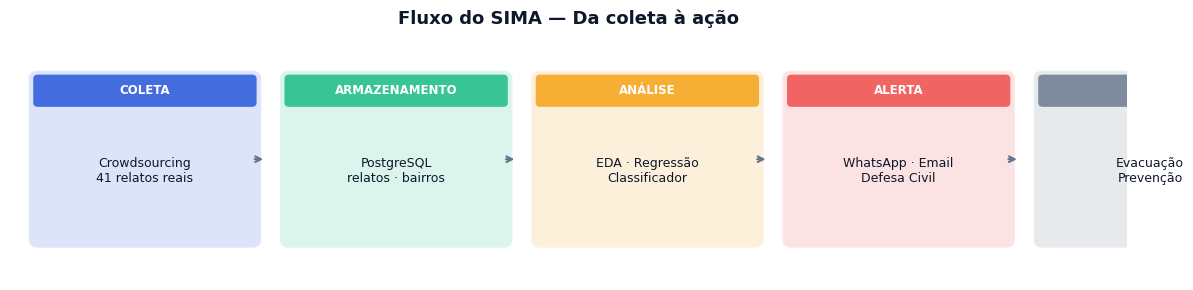

In [2]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 12); ax.set_ylim(0, 3); ax.axis('off')

etapas = [
    (0.3,  AZUL,  'COLETA',        'Crowdsourcing\n41 relatos reais'),
    (3.0,  VERDE, 'ARMAZENAMENTO', 'PostgreSQL\nrelatos · bairros'),
    (5.7,  AMBAR, 'ANÁLISE',       'EDA · Regressão\nClassificador'),
    (8.4,  VERM,  'ALERTA',        'WhatsApp · Email\nDefesa Civil'),
    (11.1, CINZA, 'AÇÃO',          'Evacuação\nPrevenção'),
]

for x, cor, titulo, desc in etapas:
    ax.add_patch(FancyBboxPatch((x, 0.5), 2.3, 2.0,
                                boxstyle='round,pad=0.1',
                                facecolor=cor, edgecolor='white',
                                linewidth=2, alpha=0.15))
    ax.add_patch(FancyBboxPatch((x, 2.2), 2.3, 0.3,
                                boxstyle='round,pad=0.05',
                                facecolor=cor, edgecolor='none', alpha=0.8))
    ax.text(x + 1.15, 2.35, titulo, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(x + 1.15, 1.35, desc, ha='center', va='center',
            fontsize=9, color=PRETO, multialignment='center')
    if x < 11.1:
        ax.annotate('', xy=(x + 2.45, 1.5), xytext=(x + 2.3, 1.5),
                    arrowprops=dict(arrowstyle='->', color=CINZA, lw=1.5))

ax.set_title('Fluxo do SIMA — Da coleta à ação', fontsize=13,
             fontweight='bold', color=PRETO, pad=10)
plt.tight_layout()
plt.show()

## 2. Perguntas de Análise

Cinco perguntas guiam toda a análise, cada uma associada a uma hipótese e a um notebook específico:

| # | Pergunta | Hipótese | Notebook |
|---|----------|----------|----------|
| P1 | Qual é a distribuição dos relatos por nível de severidade? | 82,9% são nível ALTO — cidadãos reportam situações já graves | CC3 |
| P2 | Quais bairros concentram mais ocorrências? | Bairros próximos a canais têm volume e severidade maiores | CC3 |
| P3 | Existe padrão temporal (hora/mês)? | Pico entre 16h–22h, coincidindo com chuvas vespertinas | CC3 |
| P4 | É possível prever confirmações com variáveis de severidade e hora? | Nível do relato é o preditor mais forte de engajamento | CC4 |
| P5 | Um classificador simples identifica o nível de risco? | Acurácia > 60% usando confirmações e denúncias como features | CC5 |

O gráfico abaixo mostra quantas perguntas cada notebook responde.

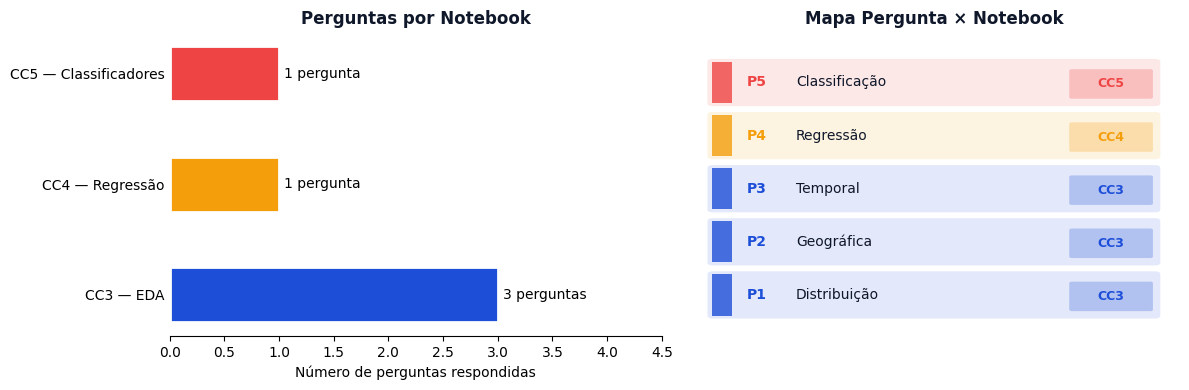

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Perguntas por notebook
nbs   = ['CC3 — EDA', 'CC4 — Regressão', 'CC5 — Classificadores']
qtds  = [3, 1, 1]
cores = [AZUL, AMBAR, VERM]

bars = axes[0].barh(nbs, qtds, color=cores, edgecolor='white', linewidth=2, height=0.5)
for bar, v in zip(bars, qtds):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{v} pergunta{"s" if v > 1 else ""}',
                 va='center', fontsize=10)
axes[0].set_xlim(0, 4.5)
axes[0].set_title('Perguntas por Notebook', fontsize=12, fontweight='bold', color=PRETO)
axes[0].set_xlabel('Número de perguntas respondidas')
axes[0].spines['left'].set_visible(False)
axes[0].tick_params(axis='y', length=0)

# Mapa pergunta × categoria
categorias = ['Distribuição', 'Geográfica', 'Temporal', 'Regressão', 'Classificação']
perguntas  = ['P1', 'P2', 'P3', 'P4', 'P5']
notebooks  = ['CC3', 'CC3', 'CC3', 'CC4', 'CC5']
cor_nb     = {'CC3': AZUL, 'CC4': AMBAR, 'CC5': VERM}

for i, (cat, perg, nb) in enumerate(zip(categorias, perguntas, notebooks)):
    cor = cor_nb[nb]
    axes[1].add_patch(FancyBboxPatch((0.05, i * 0.18 + 0.02), 0.90, 0.14,
                                     boxstyle='round,pad=0.01',
                                     facecolor=cor, edgecolor='none', alpha=0.12))
    axes[1].add_patch(FancyBboxPatch((0.05, i * 0.18 + 0.02), 0.04, 0.14,
                                     boxstyle='square,pad=0',
                                     facecolor=cor, edgecolor='none', alpha=0.8))
    axes[1].text(0.12, i * 0.18 + 0.09, perg,
                 va='center', fontsize=10, fontweight='bold', color=cor)
    axes[1].text(0.22, i * 0.18 + 0.09, cat,
                 va='center', fontsize=10, color=PRETO)
    axes[1].add_patch(FancyBboxPatch((0.78, i * 0.18 + 0.04), 0.16, 0.09,
                                     boxstyle='round,pad=0.005',
                                     facecolor=cor, edgecolor='none', alpha=0.25))
    axes[1].text(0.86, i * 0.18 + 0.085, nb,
                 ha='center', va='center', fontsize=9, color=cor, fontweight='bold')

axes[1].set_xlim(0, 1); axes[1].set_ylim(-0.05, 0.98)
axes[1].axis('off')
axes[1].set_title('Mapa Pergunta × Notebook', fontsize=12, fontweight='bold', color=PRETO)

plt.tight_layout()
plt.show()

## 3. Dados Utilizados

O banco real conta com apenas 41 relatos desde o lançamento do MVP. Isso é insuficiente para modelos de regressão e classificação. A estratégia combina três fontes:

- **Relatos reais** (41): exportados do PostgreSQL via `relatos.csv` + `bairros.csv`
- **Questionário** (42 respostas): canal preferido, frequência de alagamentos, dificuldades
- **Dados simulados** (400–800): gerados com sazonalidade horária e mensal calibrada nos dados reais

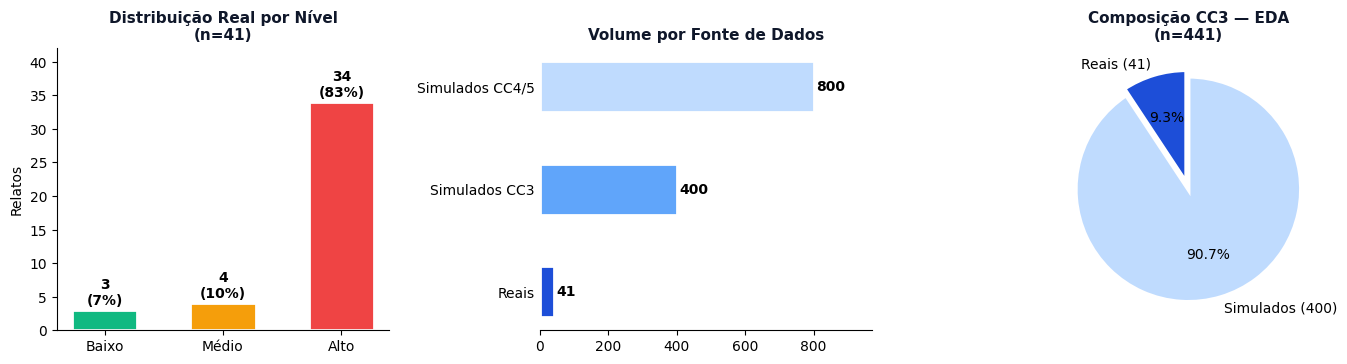

Insight: 82,9% dos relatos reais são de nível ALTO — cidadãos tendem a reportar
apenas situações já graves. Os dados simulados mantêm essa proporção.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribuição real por nível
niveis = ['Baixo', 'Médio', 'Alto']
counts = [3, 4, 34]
bars = axes[0].bar(niveis, counts, color=[VERDE, AMBAR, VERM],
                   edgecolor='white', linewidth=2, width=0.55)
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f'{v}\n({v/41*100:.0f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribuição Real por Nível\n(n=41)', fontsize=11, fontweight='bold', color=PRETO)
axes[0].set_ylabel('Relatos')
axes[0].set_ylim(0, 42)

# Volume por fonte
fontes = ['Reais', 'Simulados CC3', 'Simulados CC4/5']
volumes = [41, 400, 800]
cores_f = [AZUL, '#60a5fa', '#bfdbfe']
bars2 = axes[1].barh(fontes, volumes, color=cores_f,
                     edgecolor='white', linewidth=2, height=0.5)
for bar, v in zip(bars2, volumes):
    axes[1].text(bar.get_width() + 8,
                 bar.get_y() + bar.get_height() / 2,
                 str(v), va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, 970)
axes[1].set_title('Volume por Fonte de Dados', fontsize=11, fontweight='bold', color=PRETO)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(axis='y', length=0)

# Composição CC3 (real vs simulado)
axes[2].pie(
    [41, 400],
    labels=['Reais (41)', 'Simulados (400)'],
    colors=[AZUL, '#bfdbfe'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.06, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 10}
)
axes[2].set_title('Composição CC3 — EDA\n(n=441)', fontsize=11, fontweight='bold', color=PRETO)

plt.tight_layout(pad=2)
plt.show()

print('Insight: 82,9% dos relatos reais são de nível ALTO — cidadãos tendem a reportar')
print('apenas situações já graves. Os dados simulados mantêm essa proporção.')

## 4. Métricas Previstas

As métricas cobrem quatro categorias: **descritiva**, **correlação**, **regressão** e **classificação**. A distribuição é mostrada abaixo.

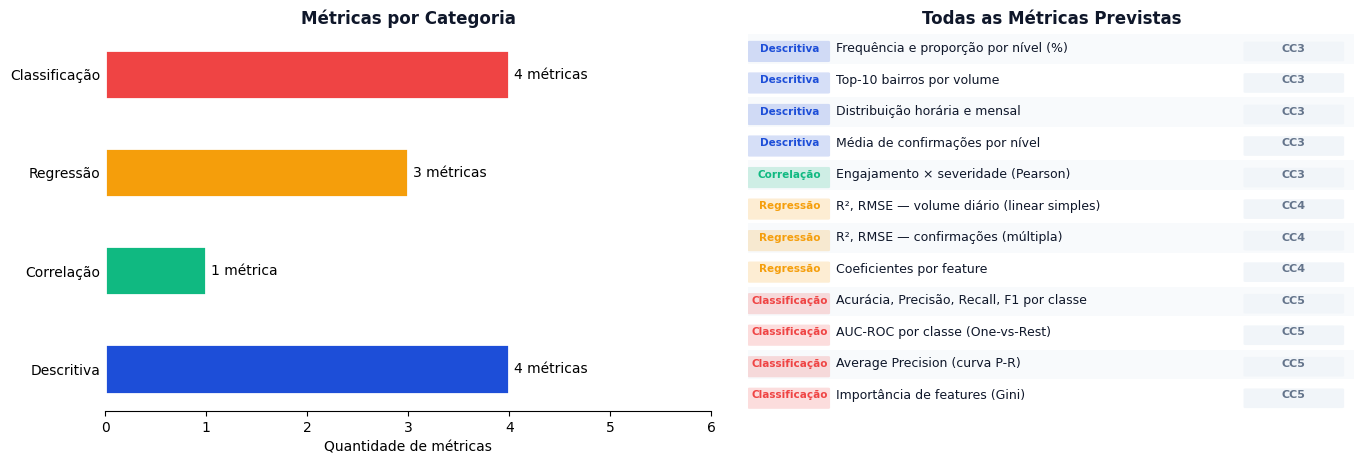

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métricas por categoria
categorias = ['Descritiva', 'Correlação', 'Regressão', 'Classificação']
qtd_metricas = [4, 1, 3, 4]
cores_cat = [AZUL, VERDE, AMBAR, VERM]

bars = axes[0].barh(categorias, qtd_metricas, color=cores_cat,
                    edgecolor='white', linewidth=2, height=0.5)
for bar, v in zip(bars, qtd_metricas):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{v} métrica{"s" if v > 1 else ""}',
                 va='center', fontsize=10)
axes[0].set_xlim(0, 6)
axes[0].set_title('Métricas por Categoria', fontsize=12, fontweight='bold', color=PRETO)
axes[0].set_xlabel('Quantidade de métricas')
axes[0].spines['left'].set_visible(False)
axes[0].tick_params(axis='y', length=0)

# Lista de métricas detalhada
metricas = [
    ('Descritiva',    AZUL,  'Frequência e proporção por nível (%)',           'CC3'),
    ('Descritiva',    AZUL,  'Top-10 bairros por volume',                      'CC3'),
    ('Descritiva',    AZUL,  'Distribuição horária e mensal',                  'CC3'),
    ('Descritiva',    AZUL,  'Média de confirmações por nível',                'CC3'),
    ('Correlação',    VERDE, 'Engajamento × severidade (Pearson)',              'CC3'),
    ('Regressão',     AMBAR, 'R², RMSE — volume diário (linear simples)',      'CC4'),
    ('Regressão',     AMBAR, 'R², RMSE — confirmações (múltipla)',             'CC4'),
    ('Regressão',     AMBAR, 'Coeficientes por feature',                       'CC4'),
    ('Classificação', VERM,  'Acurácia, Precisão, Recall, F1 por classe',     'CC5'),
    ('Classificação', VERM,  'AUC-ROC por classe (One-vs-Rest)',               'CC5'),
    ('Classificação', VERM,  'Average Precision (curva P-R)',                  'CC5'),
    ('Classificação', VERM,  'Importância de features (Gini)',                 'CC5'),
]

ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

row_h = 1 / len(metricas)
for i, (cat, cor, met, nb) in enumerate(metricas):
    y_r = 1 - (i + 1) * row_h
    bg = '#f8fafc' if i % 2 == 0 else 'white'
    ax2.add_patch(mpatches.Rectangle((0, y_r), 1, row_h - 0.005,
                                      facecolor=bg, edgecolor='none'))
    ax2.add_patch(FancyBboxPatch((0.002, y_r + 0.008), 0.13, row_h * 0.60,
                                  boxstyle='round,pad=0.003',
                                  facecolor=cor, edgecolor='none', alpha=0.18))
    ax2.text(0.068, y_r + row_h / 2, cat,
             ha='center', va='center', fontsize=7.5, color=cor, fontweight='bold')
    ax2.text(0.145, y_r + row_h / 2, met,
             va='center', fontsize=9, color=PRETO)
    ax2.add_patch(FancyBboxPatch((0.82, y_r + 0.010), 0.16, row_h * 0.55,
                                  boxstyle='round,pad=0.003',
                                  facecolor='#f1f5f9', edgecolor='none'))
    ax2.text(0.90, y_r + row_h / 2, nb,
             ha='center', va='center', fontsize=8, color=CINZA, fontweight='bold')

ax2.set_title('Todas as Métricas Previstas', fontsize=12, fontweight='bold', color=PRETO)

plt.tight_layout(pad=2)
plt.show()

## 5. Visualizações Planejadas

A grade abaixo mostra um exemplo de cada tipo de gráfico planejado nos notebooks, com justificativa perceptual.

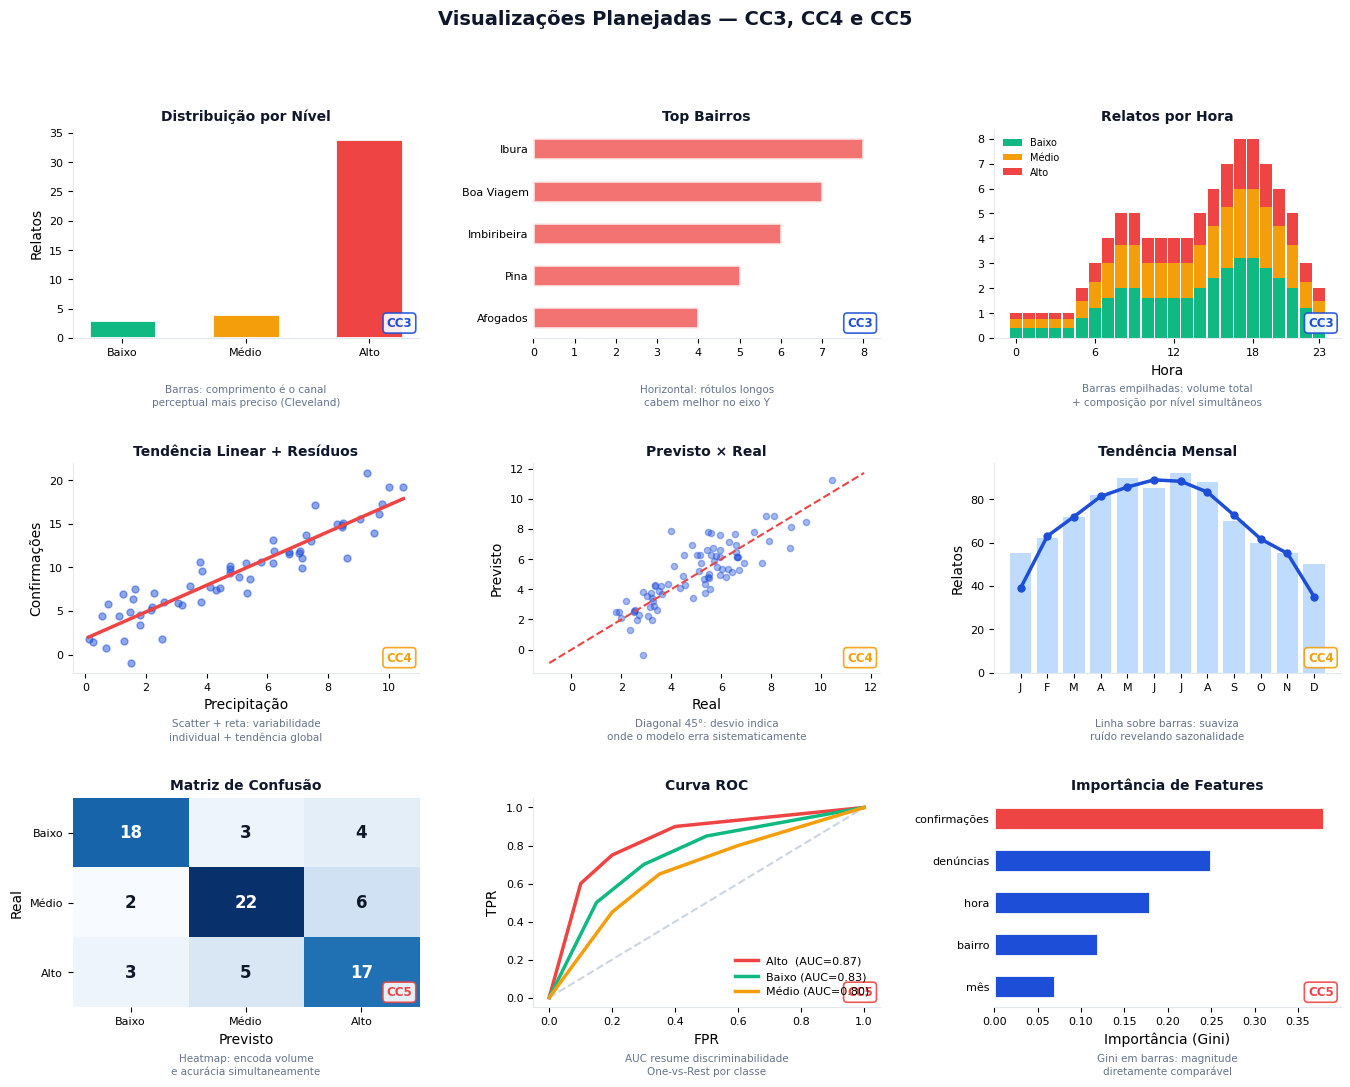

In [6]:
np.random.seed(42)
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle('Visualizações Planejadas — CC3, CC4 e CC5', fontsize=14,
             fontweight='bold', color=PRETO, y=1.01)

tags  = ['CC3', 'CC3', 'CC3', 'CC4', 'CC4', 'CC4', 'CC5', 'CC5', 'CC5']
cores_tag = {'CC3': AZUL, 'CC4': AMBAR, 'CC5': VERM}
titulos = [
    'Distribuição por Nível', 'Top Bairros', 'Relatos por Hora',
    'Tendência Linear + Resíduos', 'Previsto × Real', 'Tendência Mensal',
    'Matriz de Confusão', 'Curva ROC', 'Importância de Features',
]
justificativas = [
    'Barras: comprimento é o canal\nperceptual mais preciso (Cleveland)',
    'Horizontal: rótulos longos\ncabem melhor no eixo Y',
    'Barras empilhadas: volume total\n+ composição por nível simultâneos',
    'Scatter + reta: variabilidade\nindividual + tendência global',
    'Diagonal 45°: desvio indica\nonde o modelo erra sistematicamente',
    'Linha sobre barras: suaviza\nruído revelando sazonalidade',
    'Heatmap: encoda volume\ne acurácia simultaneamente',
    'AUC resume discriminabilidade\nOne-vs-Rest por classe',
    'Gini em barras: magnitude\ndiretamente comparável',
]

for idx, (ax, titulo, just, tag) in enumerate(zip(axes.flat, titulos, justificativas, tags)):
    cor = cores_tag[tag]
    ax.set_title(titulo, fontsize=10, fontweight='bold', color=PRETO, pad=6)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#e2e8f0')
    ax.spines['bottom'].set_color('#e2e8f0')

    if idx == 0:
        ax.bar(['Baixo', 'Médio', 'Alto'], [3, 4, 34],
               color=[VERDE, AMBAR, VERM], edgecolor='white', linewidth=2, width=0.55)
        ax.set_ylabel('Relatos')

    elif idx == 1:
        brs = ['Ibura', 'Boa Viagem', 'Imbiribeira', 'Pina', 'Afogados']
        ax.barh(brs[::-1], [8, 7, 6, 5, 4][::-1],
                color=VERM, alpha=0.75, edgecolor='white', linewidth=2, height=0.5)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

    elif idx == 2:
        hw = np.array([1,1,1,1,1,2,3,4,5,5,4,4,4,4,5,6,7,8,8,7,6,5,3,2], dtype=float)
        b1 = hw * 0.40; b2 = hw * 0.35; b3 = hw * 0.25
        ax.bar(range(24), b1, color=VERDE, edgecolor='none', width=0.9)
        ax.bar(range(24), b2, bottom=b1, color=AMBAR, edgecolor='none', width=0.9)
        ax.bar(range(24), b3, bottom=b1+b2, color=VERM, edgecolor='none', width=0.9)
        ax.set_xlabel('Hora'); ax.set_xticks([0, 6, 12, 18, 23])
        ax.legend(['Baixo', 'Médio', 'Alto'], fontsize=7, frameon=False)

    elif idx == 3:
        xr = np.linspace(0, 10, 60) + np.random.normal(0, 0.5, 60)
        yr = 1.5 * xr + 2 + np.random.normal(0, 2, 60)
        ax.scatter(xr, yr, s=25, alpha=0.5, color=AZUL)
        m, b_ = np.polyfit(xr, yr, 1)
        xl = np.linspace(xr.min(), xr.max(), 100)
        ax.plot(xl, m * xl + b_, color=VERM, lw=2.5)
        ax.set_xlabel('Precipitação'); ax.set_ylabel('Confirmações')

    elif idx == 4:
        real = np.random.normal(5, 2, 80)
        prev = real + np.random.normal(0, 1, 80)
        ax.scatter(real, prev, s=20, alpha=0.4, color=AZUL)
        lim = [min(real.min(), prev.min()) - 0.5, max(real.max(), prev.max()) + 0.5]
        ax.plot(lim, lim, '--', color=VERM, lw=1.5)
        ax.set_xlabel('Real'); ax.set_ylabel('Previsto')

    elif idx == 5:
        vm = [55, 62, 72, 82, 90, 85, 92, 88, 70, 60, 55, 50]
        mm = np.convolve(vm, np.ones(3) / 3, mode='same')
        meses_ab = ['J','F','M','A','M','J','J','A','S','O','N','D']
        ax.bar(range(12), vm, color='#bfdbfe', edgecolor='none')
        ax.plot(range(12), mm, 'o-', color=AZUL, lw=2.5, ms=5)
        ax.set_xticks(range(12)); ax.set_xticklabels(meses_ab, fontsize=8)
        ax.set_ylabel('Relatos')

    elif idx == 6:
        cm = np.array([[18, 3, 4], [2, 22, 6], [3, 5, 17]])
        ax.imshow(cm, cmap='Blues', aspect='auto')
        for i in range(3):
            for j in range(3):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if cm[i, j] > 15 else PRETO)
        ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['Baixo', 'Médio', 'Alto'])
        ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['Baixo', 'Médio', 'Alto'])
        ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
        ax.spines[:].set_visible(False)

    elif idx == 7:
        ax.plot([0, 1], [0, 1], '--', color='#cbd5e1', lw=1.5)
        for cor_r, lb, fpr, tpr in [
            (VERM,  'Alto  (AUC=0.87)', [0,.1,.2,.4,1], [0,.60,.75,.90,1]),
            (VERDE, 'Baixo (AUC=0.83)', [0,.15,.3,.5,1],[0,.50,.70,.85,1]),
            (AMBAR, 'Médio (AUC=0.80)', [0,.2,.35,.6,1],[0,.45,.65,.80,1]),
        ]:
            ax.plot(fpr, tpr, color=cor_r, lw=2.5, label=lb)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(fontsize=8, frameon=False, loc='lower right')

    elif idx == 8:
        feats = ['confirmações', 'denúncias', 'hora', 'bairro', 'mês']
        imps  = [0.38, 0.25, 0.18, 0.12, 0.07]
        cores_fi = [VERM if i == 0 else AZUL for i in range(5)]
        ax.barh(feats[::-1], imps[::-1], color=cores_fi[::-1],
                edgecolor='white', linewidth=2, height=0.55)
        ax.set_xlabel('Importância (Gini)')
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

    # Tag do notebook
    ax.set_facecolor('white')
    ax.text(0.98, 0.04, tag, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8.5,
            color=cor, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=cor, linewidth=1.2, alpha=0.9))

    # Justificativa abaixo
    ax.text(0.5, -0.22, just, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5, color=CINZA,
            multialignment='center', linespacing=1.4)

plt.tight_layout(pad=2.5)
plt.subplots_adjust(hspace=0.60)
plt.show()

## 6. Princípios de Design Visual

A paleta semântica é aplicada de forma consistente em toda a análise.

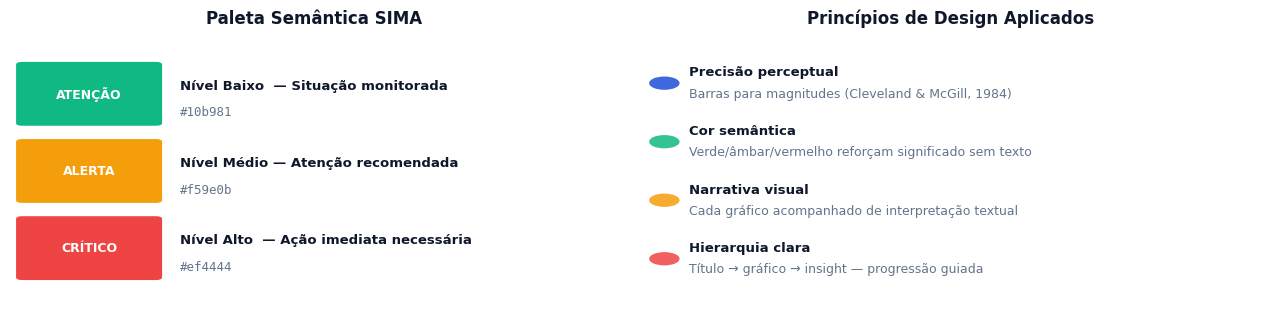

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Paleta semântica
ax = axes[0]
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Paleta Semântica SIMA', fontsize=12, fontweight='bold', color=PRETO, pad=10)

paleta = [
    (VERDE, '#10b981', 'ATENÇÃO', 'Nível Baixo  — Situação monitorada'),
    (AMBAR, '#f59e0b', 'ALERTA',  'Nível Médio — Atenção recomendada'),
    (VERM,  '#ef4444', 'CRÍTICO', 'Nível Alto  — Ação imediata necessária'),
]
for i, (cor, hex_v, label, desc) in enumerate(paleta):
    y_p = 0.68 - i * 0.29
    ax.add_patch(FancyBboxPatch((0.02, y_p), 0.22, 0.22,
                                boxstyle='round,pad=0.01',
                                facecolor=cor, edgecolor='none'))
    ax.text(0.13, y_p + 0.11, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    ax.text(0.28, y_p + 0.14, desc,
            va='center', fontsize=9.5, color=PRETO, fontweight='bold')
    ax.text(0.28, y_p + 0.04, hex_v,
            va='center', fontsize=9, color=CINZA, fontfamily='monospace')

# Princípios
ax2 = axes[1]
ax2.axis('off'); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.set_title('Princípios de Design Aplicados', fontsize=12, fontweight='bold', color=PRETO, pad=10)

principios = [
    (AZUL,  'Precisão perceptual', 'Barras para magnitudes (Cleveland & McGill, 1984)'),
    (VERDE, 'Cor semântica',       'Verde/âmbar/vermelho reforçam significado sem texto'),
    (AMBAR, 'Narrativa visual',    'Cada gráfico acompanhado de interpretação textual'),
    (VERM,  'Hierarquia clara',    'Título → gráfico → insight — progressão guiada'),
]
for i, (cor, nome, desc) in enumerate(principios):
    y_p = 0.78 - i * 0.22
    ax2.add_patch(mpatches.Circle((0.03, y_p + 0.05), 0.025,
                                   facecolor=cor, edgecolor='none', alpha=0.85))
    ax2.text(0.07, y_p + 0.09, nome, va='center', fontsize=9.5,
             fontweight='bold', color=PRETO)
    ax2.text(0.07, y_p + 0.01, desc, va='center', fontsize=9, color=CINZA)

plt.tight_layout(pad=2)
plt.show()

---

## Síntese

| Item | Detalhe |
|------|---------|
| Perguntas de análise | 5 (P1–P5), cobrindo distribuição, geografia, temporal, regressão e classificação |
| Fontes de dados | 4 (relatos reais, bairros, questionário, simulados) |
| Volume total CC3 | 441 (41 reais + 400 simulados) |
| Volume total CC4/CC5 | 800 (simulados calibrados) |
| Métricas previstas | 12 em 4 categorias |
| Tipos de gráfico | 9 (barra, horizontal, empilhada, scatter, previsto×real, mensal, confusão, ROC, importância) |
| Paleta | Verde / Âmbar / Vermelho — semanticamente mapeada a Atenção / Alerta / Crítico |